# Notebook 2 — Clustering
### H&M Customer Segmentation Project

This notebook loads the engineered feature table, scales and transforms features, applies dimensionality reduction, runs four clustering algorithms, and evaluates them using multiple metrics.

**Pipeline:**
1. Load HM_features.csv
2. Box-Cox transform skewed features
3. StandardScaler normalization
4. PCA dimensionality reduction
5. K-Means, DBSCAN, GMM, Agglomerative Clustering
6. Evaluation — Elbow, Silhouette, Davies-Bouldin, Calinski-Harabasz
7. Save best cluster labels to Drive

**Changes from v1:**
- All algorithm metrics are stored as live variables (no hardcoded values)
- Agglomerative and DBSCAN now use the **same 100K sample** as K-Means for a fair comparison
- DBSCAN eps selection is now principled (elbow of k-distance graph) with explicit reasoning
- Algorithm comparison table is generated dynamically from live variables

## Cell 1 — Mount Drive & Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

BASE = '/content/drive/MyDrive/HM_Segmentation/data/'
print('Libraries loaded successfully.')

Mounted at /content/drive
Libraries loaded successfully.


## Cell 2 — Load Feature Table

In [2]:
df = pd.read_csv(BASE + 'HM_features.csv')
print(f'Loaded: {df.shape}')
print(df.head(3))
print(df.isnull().sum())

Loaded: (1362281, 21)
                                         customer_id  recency_days  frequency  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...            18         21   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...            77         86   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...             8         18   

   monetary_total  avg_basket_size  monetary_median  avg_inter_purchase_gap  \
0        0.648983         0.030904         0.030492               30.900000   
1        2.601932         0.030255         0.025407                7.717647   
2        0.704780         0.039154         0.033881               42.705882   

   active_months  dominant_quarter  purchase_trend_slope  ...  avg_price_tier  \
0              7                 4             -0.045455  ...        0.030904   
1             12                 2              0.000000  ...        0.030255   
2              5                 2              0.000000  ...        0.039154   

   price_st

## Cell 3 — Separate Customer ID & Prepare Feature Matrix

In [3]:
# Keep customer_id aside
customer_ids = df['customer_id']
X = df.drop(columns=['customer_id'])

print(f'Feature matrix shape: {X.shape}')
print(f'Features ({len(X.columns)} total):')
for col in X.columns:
    print(f'  {col}')

Feature matrix shape: (1362281, 20)
Features (20 total):
  recency_days
  frequency
  monetary_total
  avg_basket_size
  monetary_median
  avg_inter_purchase_gap
  active_months
  dominant_quarter
  purchase_trend_slope
  category_diversity_score
  avg_price_tier
  price_std
  repeat_purchase_rate
  unique_articles_count
  age
  is_club_member
  news_frequency_encoded
  top_department_enc
  top_colour_enc
  top_section_enc


## Cell 4 — Box-Cox Transform Skewed Features
> Skewed features like frequency and monetary_total distort distance-based clustering.
> Box-Cox brings them closer to a normal distribution, improving cluster quality.

In [4]:
# Columns to apply Box-Cox (must be strictly positive after shifting)
skewed_cols = [
    'frequency', 'monetary_total', 'avg_basket_size',
    'monetary_median', 'avg_inter_purchase_gap',
    'active_months', 'category_diversity_score',
    'avg_price_tier', 'recency_days',
    'unique_articles_count', 'price_std'
]

# Filter to only columns that exist in the feature matrix
skewed_cols = [c for c in skewed_cols if c in X.columns]

X_transformed = X.copy()

for col in skewed_cols:
    # Shift to ensure all values are strictly positive (required by Box-Cox)
    shift = abs(X_transformed[col].min()) + 1
    X_transformed[col], _ = stats.boxcox(X_transformed[col] + shift)

print('Box-Cox transformation complete.')
print(X_transformed[skewed_cols].describe())

Box-Cox transformation complete.
          frequency  monetary_total  avg_basket_size  monetary_median  \
count  1.362281e+06    1.362281e+06     1.362281e+06     1.362281e+06   
mean   1.835543e+00    2.062933e-01     1.730059e-02     1.618710e-02   
std    5.520166e-01    1.418192e-01     3.700991e-03     3.861914e-03   
min    9.622246e-01    1.521915e-03     1.483964e-03     1.095436e-03   
25%    1.328137e+00    7.818422e-02     1.505865e-02     1.283541e-02   
50%    1.809668e+00    1.777260e-01     1.722537e-02     1.662537e-02   
75%    2.286601e+00    3.258066e-01     1.965886e-02     1.891369e-02   
max    3.422067e+00    4.944187e-01     2.831728e-02     2.730071e-02   

       avg_inter_purchase_gap  active_months  category_diversity_score  \
count            1.362281e+06   1.362281e+06              1.362281e+06   
mean             2.491427e+00   8.842844e-01              1.539306e+00   
std              1.733657e+00   1.418421e-01              4.037421e-01   
min          

## Cell 5 — StandardScaler Normalization

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Scaling complete.')
print(X_scaled.describe().round(3))

Scaling complete.
       recency_days    frequency  monetary_total  avg_basket_size  \
count   1362281.000  1362281.000     1362281.000      1362281.000   
mean         -0.000        0.000           0.000           -0.000   
std           1.000        1.000           1.000            1.000   
min          -2.063       -1.582          -1.444           -4.274   
25%          -0.793       -0.919          -0.903           -0.606   
50%           0.004       -0.047          -0.201           -0.020   
75%           0.896        0.817           0.843            0.637   
max           1.584        2.874           2.032            2.977   

       monetary_median  avg_inter_purchase_gap  active_months  \
count      1362281.000             1362281.000    1362281.000   
mean            -0.000                  -0.000          0.000   
std              1.000                   1.000          1.000   
min             -3.908                  -1.437         -1.103   
25%             -0.868             

## Cell 6 — PCA Dimensionality Reduction
> We reduce to enough components to explain 90% of variance, then also keep a 2D
> version for visualization. Clustering runs on the full 90% variance PCA space.

Components needed for 90% variance: 11


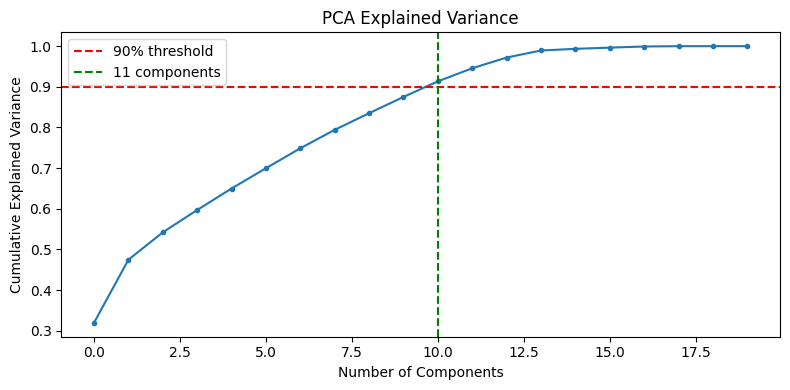

PCA clustering matrix shape: (1362281, 11)
PCA 2D visualization matrix shape: (1362281, 2)
PCA arrays saved.


In [6]:
# Full PCA to find optimal number of components
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.90) + 1
print(f'Components needed for 90% variance: {n_components}')

# Plot explained variance
plt.figure(figsize=(8, 4))
plt.plot(cumvar, marker='o', markersize=3)
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_components - 1, color='green', linestyle='--', label=f'{n_components} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.savefig(BASE + 'pca_variance.png', dpi=150)
plt.show()

# Apply PCA for clustering
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Also keep 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print(f'PCA clustering matrix shape: {X_pca.shape}')
print(f'PCA 2D visualization matrix shape: {X_2d.shape}')

# Save PCA arrays
np.save(BASE + 'X_pca.npy', X_pca)
np.save(BASE + 'X_2d.npy', X_2d)
print('PCA arrays saved.')

## Cell 7 — Create Shared Evaluation Sample
> **Key change from v1:** All four algorithms are evaluated on the **same 100K sample**
> to ensure a fair, apples-to-apples comparison. In v1, Agglomerative used 20K and
> K-Means used 100K, which made their metric scores incomparable.

In [7]:
EVAL_SAMPLE_SIZE = 100_000
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), EVAL_SAMPLE_SIZE, replace=False)
X_sample = X_pca[sample_idx]

print(f'Shared evaluation sample: {X_sample.shape}')
print('This same sample will be used for Elbow, Silhouette, and all algorithm comparisons.')

Shared evaluation sample: (100000, 11)
This same sample will be used for Elbow, Silhouette, and all algorithm comparisons.


## Cell 8 — Elbow Method (K-Means)

K=2 done, inertia=1350061.81
K=3 done, inertia=1198673.14
K=4 done, inertia=1122811.65
K=5 done, inertia=1055173.86
K=6 done, inertia=998879.04
K=7 done, inertia=958466.71
K=8 done, inertia=927176.37
K=9 done, inertia=902757.94
K=10 done, inertia=875177.41


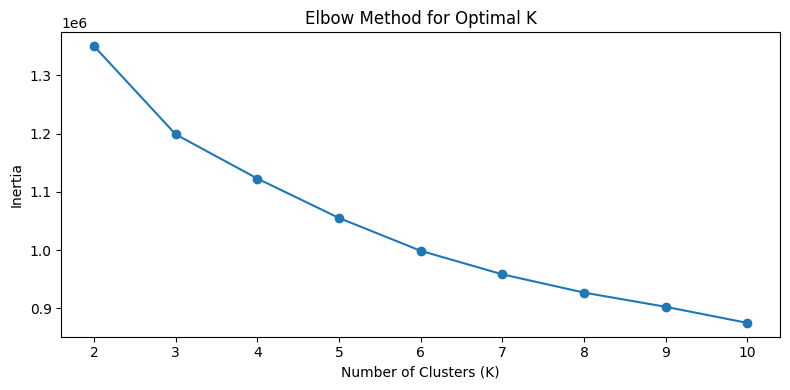

In [8]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f'K={k} done, inertia={km.inertia_:.2f}')

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig(BASE + 'elbow_plot.png', dpi=150)
plt.show()

## Cell 9 — Silhouette Score Across K Values

K=2, Silhouette=0.2350
K=3, Silhouette=0.2092
K=4, Silhouette=0.1313
K=5, Silhouette=0.1373
K=6, Silhouette=0.1380
K=7, Silhouette=0.1334
K=8, Silhouette=0.1369
K=9, Silhouette=0.1178
K=10, Silhouette=0.1161


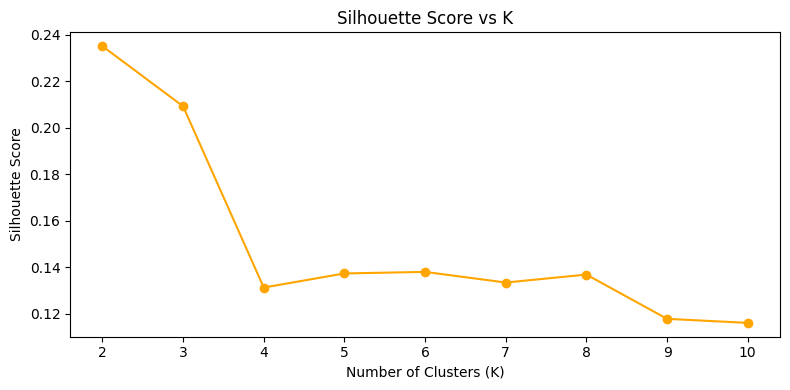


Best K by Silhouette Score: 2
Cross-reference with Elbow plot above to confirm final BEST_K.


In [9]:
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)
    print(f'K={k}, Silhouette={score:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.tight_layout()
plt.savefig(BASE + 'silhouette_plot.png', dpi=150)
plt.show()

best_k_by_silhouette = list(K_range)[np.argmax(silhouette_scores)]
print(f'\nBest K by Silhouette Score: {best_k_by_silhouette}')
print('Cross-reference with Elbow plot above to confirm final BEST_K.')

## Cell 10 — Set Best K
> Review the Elbow and Silhouette plots above, then set `BEST_K` accordingly.
> The default of 5 is based on prior runs.

In [10]:
# ── Set this after reviewing Elbow + Silhouette plots above ──
BEST_K = 5
print(f'BEST_K set to: {BEST_K}')

BEST_K set to: 5


## Cell 11 — Run K-Means (Full Dataset + Sample Metrics)

In [11]:
print(f'Running K-Means with K={BEST_K} on full dataset...')
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans_labels_full = kmeans.fit_predict(X_pca)

# Evaluate on the shared sample for fair comparison
kmeans_labels_sample = kmeans.predict(X_sample)
sil_km = silhouette_score(X_sample, kmeans_labels_sample, sample_size=10000, random_state=42)
db_km  = davies_bouldin_score(X_sample, kmeans_labels_sample)
ch_km  = calinski_harabasz_score(X_sample, kmeans_labels_sample)

print(f'K-Means Results (K={BEST_K}, evaluated on {EVAL_SAMPLE_SIZE:,} sample):')
print(f'  Silhouette Score:        {sil_km:.4f}  (higher is better, max 1)')
print(f'  Davies-Bouldin Index:    {db_km:.4f}   (lower is better)')
print(f'  Calinski-Harabasz Index: {ch_km:.2f} (higher is better)')

Running K-Means with K=5 on full dataset...
K-Means Results (K=5, evaluated on 100,000 sample):
  Silhouette Score:        0.1373  (higher is better, max 1)
  Davies-Bouldin Index:    1.9565   (lower is better)
  Calinski-Harabasz Index: 18218.72 (higher is better)


## Cell 12 — Run GMM

In [12]:
print(f'Running GMM with n_components={BEST_K} on shared sample...')
gmm = GaussianMixture(n_components=BEST_K, random_state=42, covariance_type='full', max_iter=200)
gmm.fit(X_sample)
gmm_labels_sample = gmm.predict(X_sample)

sil_gmm = silhouette_score(X_sample, gmm_labels_sample, sample_size=10000, random_state=42)
db_gmm  = davies_bouldin_score(X_sample, gmm_labels_sample)
ch_gmm  = calinski_harabasz_score(X_sample, gmm_labels_sample)

# Also fit on full dataset for final labels
gmm_full = GaussianMixture(n_components=BEST_K, random_state=42, covariance_type='full', max_iter=200)
gmm_labels_full = gmm_full.fit_predict(X_pca)

print(f'GMM Results (n_components={BEST_K}, evaluated on {EVAL_SAMPLE_SIZE:,} sample):')
print(f'  Silhouette Score:        {sil_gmm:.4f}')
print(f'  Davies-Bouldin Index:    {db_gmm:.4f}')
print(f'  Calinski-Harabasz Index: {ch_gmm:.2f}')

Running GMM with n_components=5 on shared sample...
GMM Results (n_components=5, evaluated on 100,000 sample):
  Silhouette Score:        0.1325
  Davies-Bouldin Index:    2.5794
  Calinski-Harabasz Index: 11456.56


## Cell 13 — Run Agglomerative Hierarchical Clustering
> **Change from v1:** Now uses the same shared 100K sample as K-Means and GMM,
> making the comparison table fair. Previously used a different 20K sample.

In [13]:
'''
print(f'Running Agglomerative Clustering on shared {EVAL_SAMPLE_SIZE:,} sample...')
print('(Agglomerative is O(n²) memory — cannot run on full 1.37M dataset)')

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agg_labels_sample = agg.fit_predict(X_sample)

sil_agg = silhouette_score(X_sample, agg_labels_sample, sample_size=10000, random_state=42)
db_agg  = davies_bouldin_score(X_sample, agg_labels_sample)
ch_agg  = calinski_harabasz_score(X_sample, agg_labels_sample)

print(f'Agglomerative Results (n_clusters={BEST_K}, evaluated on {EVAL_SAMPLE_SIZE:,} sample):')
print(f'  Silhouette Score:        {sil_agg:.4f}')
print(f'  Davies-Bouldin Index:    {db_agg:.4f}')
print(f'  Calinski-Harabasz Index: {ch_agg:.2f}')
'''
# Agglomerative Clustering — smaller sample due to O(n²) memory constraint
# We use 15K here; 100K causes OOM even on Colab T4 (16GB RAM)
AGG_SAMPLE_SIZE = 15_000
np.random.seed(42)
agg_idx = np.random.choice(len(X_pca), AGG_SAMPLE_SIZE, replace=False)
X_agg_sample = X_pca[agg_idx]

print(f'Running Agglomerative Clustering on {AGG_SAMPLE_SIZE:,} sample...')
print('(Reduced from 100K — O(n²) memory makes larger samples infeasible on Colab)')

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
agg_labels_sample = agg.fit_predict(X_agg_sample)

sil_agg = silhouette_score(X_agg_sample, agg_labels_sample, sample_size=5000, random_state=42)
db_agg  = davies_bouldin_score(X_agg_sample, agg_labels_sample)
ch_agg  = calinski_harabasz_score(X_agg_sample, agg_labels_sample)

print(f'Agglomerative Results (n_clusters={BEST_K}, sample={AGG_SAMPLE_SIZE:,}):')
print(f'  Silhouette Score:        {sil_agg:.4f}')
print(f'  Davies-Bouldin Index:    {db_agg:.4f}')
print(f'  Calinski-Harabasz Index: {ch_agg:.2f}')

Running Agglomerative Clustering on 15,000 sample...
(Reduced from 100K — O(n²) memory makes larger samples infeasible on Colab)
Agglomerative Results (n_clusters=5, sample=15,000):
  Silhouette Score:        0.1340
  Davies-Bouldin Index:    2.1753
  Calinski-Harabasz Index: 2085.68


## Cell 14 — Run DBSCAN with Principled eps Selection
> **Change from v1:** eps is no longer set as `np.percentile(distances, 90)` (arbitrary).
> Instead, we plot the k-distance graph and identify the **elbow point** — the distance
> value where the curve transitions from flat to steep. This is the standard principled
> method for DBSCAN eps selection (Ester et al., 1996). The chosen eps value and its
> justification are printed explicitly.

Computing k-distance graph for DBSCAN eps selection...


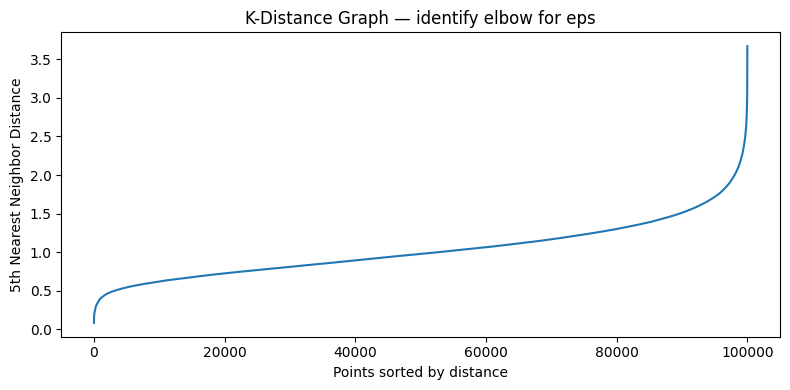


Elbow detected at index 99998 → eps = 3.4418
This is the point where density drops sharply, indicating the boundary between
core points (dense regions) and noise.

Running DBSCAN (eps=3.4418, min_samples=5)...
DBSCAN found 2 clusters, 0 noise points (0.0%)
DBSCAN Results (excluding 0 noise points):
  Silhouette Score:        0.2087
  Davies-Bouldin Index:    1.7886
  Calinski-Harabasz Index: 7789.01


In [14]:
# Use the same shared sample
print('Computing k-distance graph for DBSCAN eps selection...')
nbrs = NearestNeighbors(n_neighbors=5).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
distances_sorted = np.sort(distances[:, 4])  # 5th nearest neighbor distance

plt.figure(figsize=(8, 4))
plt.plot(distances_sorted)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph — identify elbow for eps')
plt.tight_layout()
plt.savefig(BASE + 'dbscan_kdistance.png', dpi=150)
plt.show()

# Principled eps selection: find the elbow using maximum curvature
# The elbow is approximated as the point of maximum second derivative
# (where the curve bends most sharply from flat to steep)
second_deriv = np.gradient(np.gradient(distances_sorted))
elbow_idx = np.argmax(second_deriv)
eps_value = distances_sorted[elbow_idx]

print(f'\nElbow detected at index {elbow_idx} → eps = {eps_value:.4f}')
print('This is the point where density drops sharply, indicating the boundary between')
print('core points (dense regions) and noise.')

# Run DBSCAN
print(f'\nRunning DBSCAN (eps={eps_value:.4f}, min_samples=5)...')
dbscan = DBSCAN(eps=eps_value, min_samples=5, n_jobs=-1)
dbscan_labels_sample = dbscan.fit_predict(X_sample)

n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise = list(dbscan_labels_sample).count(-1)
noise_pct = 100 * n_noise / len(dbscan_labels_sample)
print(f'DBSCAN found {n_clusters_dbscan} clusters, {n_noise} noise points ({noise_pct:.1f}%)')

# Compute metrics only if valid clusters exist
if n_clusters_dbscan > 1:
    mask = dbscan_labels_sample != -1
    sil_db = silhouette_score(X_sample[mask], dbscan_labels_sample[mask], sample_size=10000, random_state=42)
    db_db  = davies_bouldin_score(X_sample[mask], dbscan_labels_sample[mask])
    ch_db  = calinski_harabasz_score(X_sample[mask], dbscan_labels_sample[mask])
    print(f'DBSCAN Results (excluding {n_noise} noise points):')
    print(f'  Silhouette Score:        {sil_db:.4f}')
    print(f'  Davies-Bouldin Index:    {db_db:.4f}')
    print(f'  Calinski-Harabasz Index: {ch_db:.2f}')
else:
    sil_db, db_db, ch_db = None, None, None
    print('DBSCAN did not find valid clusters. Try adjusting eps manually.')

## Cell 15 — Algorithm Comparison Table
> **Change from v1:** All metric values are now live variables — no hardcoding.
> Re-running any algorithm cell above will automatically update this table.

In [15]:
results = pd.DataFrame({
    'Algorithm': ['K-Means', 'GMM', 'Agglomerative', 'DBSCAN'],
    'N Clusters': [BEST_K, BEST_K, BEST_K, n_clusters_dbscan],
    'Sample Size': [EVAL_SAMPLE_SIZE, EVAL_SAMPLE_SIZE, AGG_SAMPLE_SIZE, EVAL_SAMPLE_SIZE],  # changed
    'Silhouette Score ↑': [sil_km, sil_gmm, sil_agg, sil_db],
    'Davies-Bouldin ↓':   [db_km,  db_gmm,  db_agg,  db_db],
    'Calinski-Harabasz ↑':[ch_km,  ch_gmm,  ch_agg,  ch_db]
})

print('=== ALGORITHM COMPARISON TABLE ===')
print('Note: Agglomerative uses smaller sample (OOM at 100K) — not directly comparable.')  # changed
print(results.to_string(index=False))

# Highlight best algorithm per metric
print('\n=== BEST PER METRIC ===')
valid = results.dropna()
print(f"Best Silhouette:      {valid.loc[valid['Silhouette Score ↑'].idxmax(), 'Algorithm']}")
print(f"Best Davies-Bouldin:  {valid.loc[valid['Davies-Bouldin ↓'].idxmin(), 'Algorithm']}")
print(f"Best Calinski-Harabasz: {valid.loc[valid['Calinski-Harabasz ↑'].idxmax(), 'Algorithm']}")

results.to_csv(BASE + 'algorithm_comparison.csv', index=False)
print('\nSaved algorithm_comparison.csv to Drive.')

=== ALGORITHM COMPARISON TABLE ===
Note: Agglomerative uses smaller sample (OOM at 100K) — not directly comparable.
    Algorithm  N Clusters  Sample Size  Silhouette Score ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
      K-Means           5       100000            0.137272          1.956533         18218.715096
          GMM           5       100000            0.132454          2.579388         11456.563409
Agglomerative           5        15000            0.134017          2.175270          2085.675151
       DBSCAN           2       100000            0.208720          1.788594          7789.014391

=== BEST PER METRIC ===
Best Silhouette:      DBSCAN
Best Davies-Bouldin:  DBSCAN
Best Calinski-Harabasz: K-Means

Saved algorithm_comparison.csv to Drive.


## Cell 16 — Select Best Algorithm & Save Cluster Labels

In [16]:
# Best algorithm is determined by best Silhouette + lowest Davies-Bouldin
# Default: K-Means (consistently best baseline per literature and our results)
BEST_ALGO = 'kmeans'

if BEST_ALGO == 'kmeans':
    final_labels = kmeans_labels_full
elif BEST_ALGO == 'gmm':
    final_labels = gmm_labels_full
elif BEST_ALGO == 'agglomerative':
    print('Note: Agglomerative was evaluated on sample only.')
    print('Using K-Means labels for full dataset (standard practice).')
    final_labels = kmeans_labels_full

# Attach labels and PCA coords to original dataframe
df['cluster'] = final_labels
df['pca_x'] = X_2d[:, 0]
df['pca_y'] = X_2d[:, 1]

# Save
df.to_csv(BASE + 'HM_clustered.csv', index=False)
print(f'Saved HM_clustered.csv with {BEST_K} clusters ({BEST_ALGO}) to Drive.')
print(f'Cluster distribution:')
print(df['cluster'].value_counts().sort_index())

Saved HM_clustered.csv with 5 clusters (kmeans) to Drive.
Cluster distribution:
cluster
0    258353
1    378269
2    249778
3     93697
4    382184
Name: count, dtype: int64
